In [1]:
#!pip install pyjstat

In [2]:
import json
import requests
from pyjstat import pyjstat
import pandas as pd


with open("skaddeitrafikk.json", "r") as file:
    ssbquery_data = json.load(file)

ssbquery = ssbquery_data["queryObj"]
postUrl  = ssbquery_data["postUrl"]
tabellnummer = ssbquery_data["tableIdForQuery"]

response_ssb = requests.post(postUrl, json=ssbquery)


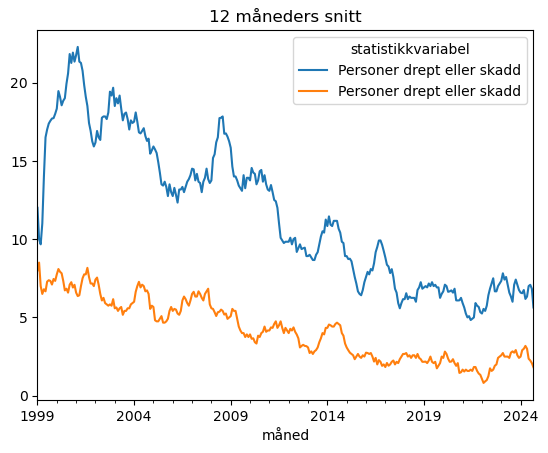

<Axes: xlabel='måned'>

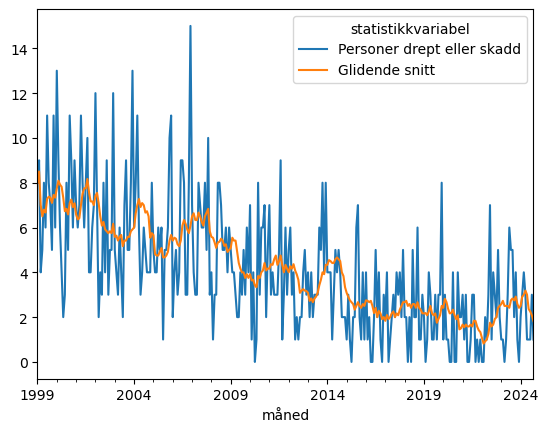

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

dataset = pyjstat.Dataset.read(response_ssb.text)
df = dataset.write("dataframe")
df_id = dataset.write("dataframe", naming="id")

df["måned"] = pd.to_datetime(df["måned"], format="%YM%m")
df=df.pivot(index=["kjønn", "måned"], columns="statistikkvariabel", values="value")

df_kvinner = df.loc["Kvinner"]
df_menn = df.loc["Menn"]
    
verdier = set(df.index.get_level_values(level=0))
verdier

fig, ax = plt.subplots(1,1)
moving_avg = []
for kj in verdier:
    df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4)).mean().plot(ax=ax, label="12mnders snitt")
    moving_avg.append(df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4)).mean())
    #print(list(df.loc[kj].rolling(window=datetime.timedelta(weeks=12*4))["Personer drept eller skadd"]))

moving_avg.reverse()
s = pd.concat(moving_avg)
s.index = df.index
df2 = df.copy()
df2["Glidende snitt"] = s
plt.title("12 måneders snitt")
plt.show()
df2.loc["Kvinner"].plot()

statistikkvariabel,måned,Personer drept eller skadd
statistikkvariabel,,
måned,1.000000,-0.691399
Personer drept eller skadd,-0.691399,1.000000


0.478031993812535


/tmp/ipykernel_598/266422546.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kvinner["modell"] = model_k.predict(x)


<Axes: xlabel='måned', ylabel='Personer drept eller skadd'>

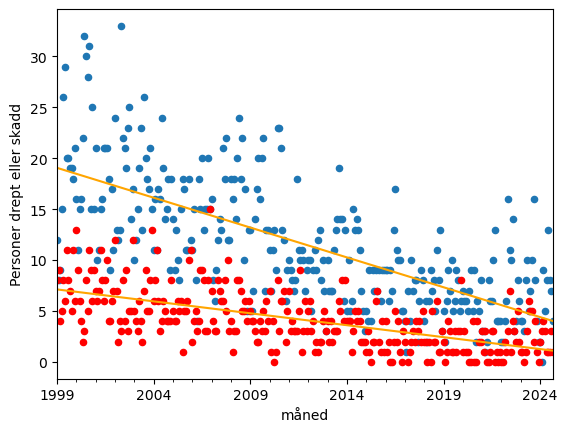

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression

ax = df2.xs("Menn", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd")
display(df.xs("Menn", level=0).reset_index().corr())


df_kvinner = df.xs("Kvinner", level=0)
df_menn = df.loc["Menn"]

x = df_menn.reset_index()[["måned"]]
x["tid"] = x["måned"]-x["måned"].iloc[0]
x["tid"] = x["tid"].dt.days
x = x[["tid"]]

y = df_menn[["Personer drept eller skadd"]]

y_k = df_kvinner[["Personer drept eller skadd"]]

model = LinearRegression()
model_k = LinearRegression()

reg = model.fit(x,y)
reg_k = model_k.fit(x,y_k)
print(reg.score(x,y))

df_menn["modell"] = model.predict(x)
df_menn["modell"].plot(ax=ax, color="orange")
df2.xs("Menn", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd", ax=ax)

df_kvinner["modell"] = model_k.predict(x)
df_kvinner["modell"].plot(ax=ax,color="orange")
df2.xs("Kvinner", level=0).reset_index().plot.scatter(x="måned", y="Personer drept eller skadd", ax=ax, color="red")

In [28]:
df = df2.copy()

df = df.rename(columns={"Personer drept eller skadd": "personer"})
df["tid"] = df["tid"].map(lambda x: 12*x.days/365)
df = df.query("kjønn == 'Kvinner'")

In [29]:
# enkel lineær regresjon
formel = 'personer ~ tid'
#df = df2.rename(columns={"Personer drept eller skadd": "personer"})
display(df)
modell = smf.ols(formel, data = df)
resultat = modell.fit()

resultat.summary()

statistikkvariabel,kjønn,måned,personer,Glidende snitt,tid
0,Kvinner,1999-01-01,8,8.000000,0.000000
1,Kvinner,1999-02-01,9,8.500000,1.019178
2,Kvinner,1999-03-01,4,7.000000,1.939726
3,Kvinner,1999-04-01,5,6.500000,2.958904
4,Kvinner,1999-05-01,8,6.800000,3.945205
...,...,...,...,...,...
304,Kvinner,2024-05-01,1,3.000000,304.175342
305,Kvinner,2024-06-01,1,2.363636,305.194521
306,Kvinner,2024-07-01,1,2.250000,306.180822
307,Kvinner,2024-08-01,3,2.083333,307.200000


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               personer   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     184.3
Date:                Wed, 13 Nov 2024   Prob (F-statistic):           3.31e-33
Time:                        11:07:04   Log-Likelihood:                -688.75
No. Observations:                 309   AIC:                             1382.
Df Residuals:                     307   BIC:                             1389.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.1201      0.256     27.818      0.000       6.616       7.624
tid           -0.0195      0.001    -13.576      0.000      -0.022      -0.017
==============================================================================
Omnibus:                       31.888   Durbin-Watson:                   1.639
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.199
Skew:                           0.762   Prob(JB):                     1.87e-09
Kurtosis:                       3.893   Cond. No.                         355.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
ax = df.loc["Kvinner"].plot()
df.loc["Menn"].plot(ax=ax)